# Stage 4 — Rayleigh/Rician Fading + Cross-Channel Robustness

AWGN (stage 3) only adds noise — the signal's magnitude and phase pass through
untouched. Real wireless channels also **fade**: multipath propagation makes the
channel gain itself random, `y = h*x + w`, where `h` is a complex random variable
representing constructive/destructive interference across multiple signal paths.

- **Rayleigh fading**: no line-of-sight path, `h ~ CN(0,1)` — pure scattering.
- **Rician fading**: line-of-sight path *plus* scattering, parameterized by
  `K` (Rician K-factor) = ratio of LoS power to scattered power. `K -> inf` recovers
  AWGN (`h=1`, no fading); `K=0` recovers Rayleigh (no LoS).
- **Perfect-CSI equalization**: assume the receiver knows `h` exactly (channel state
  information) and divides it out, `x_hat = y/h`, before decoding — isolates the
  fading's effect on *noise amplification* from the harder problem of estimating `h`
  itself (estimated CSI is out of scope, docs OUT list).

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from deepscs.audio import W, F, L, deframe, sdr
from deepscs.data import ToyDataset
from deepscs.model import DeepSC_S
from deepscs.channel import ChannelLayer
from deepscs.viz import plot_constellation

torch.manual_seed(0)
np.random.seed(0)
plt.rcParams["figure.figsize"] = (10, 3)

# CPU, not MPS: MPS's autograd for torch.complex ops (used by the channel layer)
# doesn't support backward through non-contiguous views yet; toy-scale training
# (<=32 clips, 115k params) is fast enough on CPU that it doesn't matter here.
device = torch.device("cpu")
print("device:", device)

device: cpu


## Constellation: AWGN vs Rayleigh vs Rician

AWGN spreads points in an additive cloud around their original position. Fading instead rotates and rescales each point (multiplicative `h`) before adding noise — Rayleigh scatters most severely (h magnitude and phase both fully random); Rician keeps a dominant phase/magnitude (the LoS component) with a smaller scatter around it.

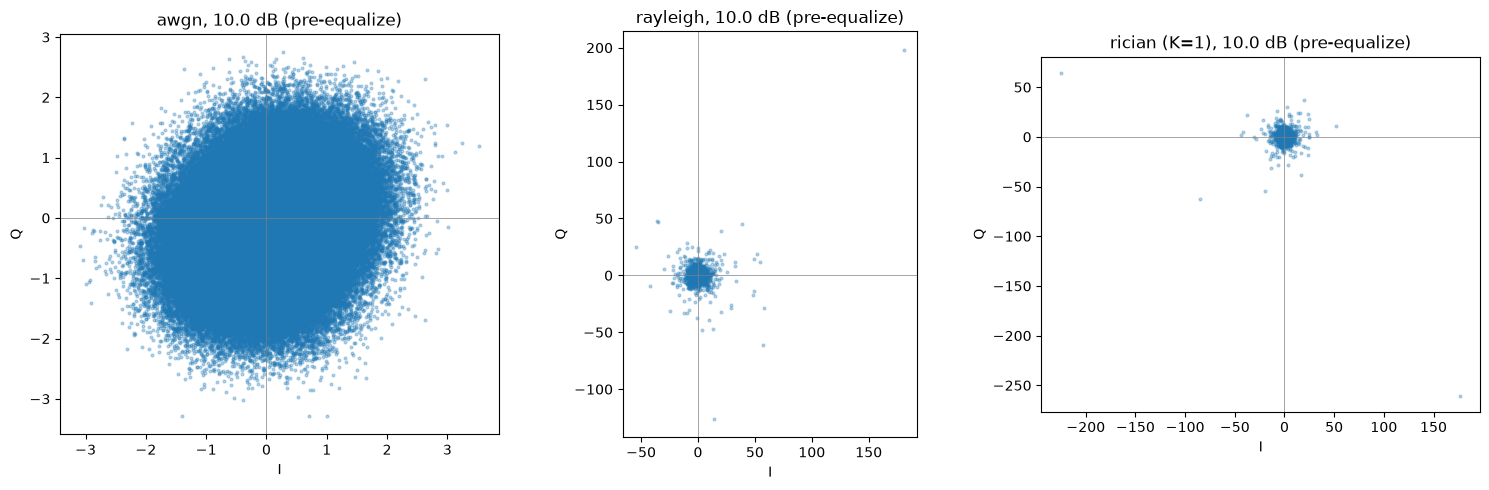

In [2]:
model = DeepSC_S(depth=8, n_blocks=4).to(device)
train_ds = ToyDataset(n=4, length=W, seed=0)
waveforms = torch.stack([train_ds[i] for i in range(len(train_ds))]).to(device)
x = waveforms.view(-1, 1, F, L)

from deepscs.channel import to_iq, power_norm
with torch.no_grad():
    z = model.channel_encoder(model.semantic_encoder(x))
    x_iq = power_norm(to_iq(z))

snr = 10.0
channels = {
    "awgn": ChannelLayer("awgn", snr_db=snr),
    "rayleigh": ChannelLayer("rayleigh", snr_db=snr),
    "rician (K=1)": ChannelLayer("rician", snr_db=snr, rician_k=1.0),
}

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, (name, ch) in zip(axes, channels.items()):
    with torch.no_grad():
        y_pre_equalize = ch.impl.forward(x_iq, snr)
    plot_constellation(ax, y_pre_equalize.cpu().numpy(), title=f"{name}, {snr} dB (pre-equalize)")
plt.tight_layout()
plt.show()

## Channel gain `h` magnitude distribution

Rayleigh's `|h|` follows a Rayleigh distribution (mode > 0, long tail — deep fades are common). Rician's `|h|` clusters tighter around its LoS mean; as `K` grows the distribution collapses toward a spike at `|h|=1` (AWGN).

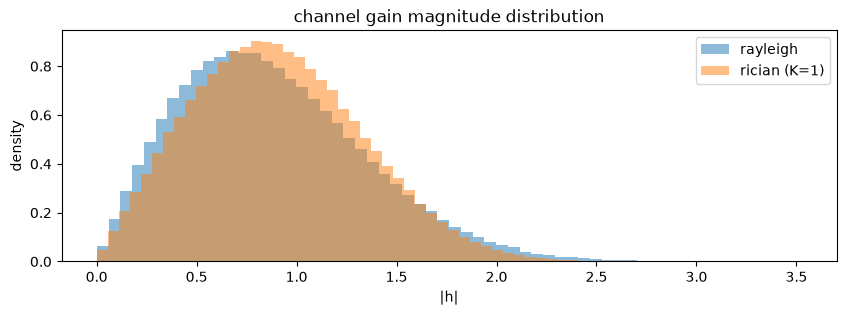

In [3]:
fig, ax = plt.subplots()
for name, ch in [("rayleigh", channels["rayleigh"]), ("rician (K=1)", channels["rician (K=1)"])]:
    h = ch.impl.last_h.abs().cpu().numpy().ravel()
    ax.hist(h, bins=60, alpha=0.5, density=True, label=name)
ax.set_xlabel("|h|")
ax.set_ylabel("density")
ax.legend()
ax.set_title("channel gain magnitude distribution")
plt.show()

## Train once per channel, test on all

Train two models — one on AWGN only, one on Rayleigh only — then evaluate every model
on every channel type without retraining. This is the paper's headline robustness
claim: joint source-channel coding should degrade gracefully even when the *test*
channel differs from the *training* channel.

In [4]:
def train_model(channel_kind, n_epochs=1500, rician_k=1.0):
    m = DeepSC_S(depth=8, n_blocks=4).to(device)
    opt = torch.optim.Adam(m.parameters(), lr=1e-3)
    loss_fn = nn.MSELoss()
    ch = ChannelLayer(channel_kind, snr_db=10.0, rician_k=rician_k)
    for _ in range(n_epochs):
        ch.snr_db = float(np.random.uniform(0, 20))
        opt.zero_grad()
        x_hat = m(x, channel=ch)
        loss = loss_fn(x_hat, x)
        loss.backward()
        opt.step()
    return m

models = {
    "awgn": train_model("awgn"),
    "rayleigh": train_model("rayleigh"),
}
print("trained on:", list(models.keys()))

trained on: ['awgn', 'rayleigh']


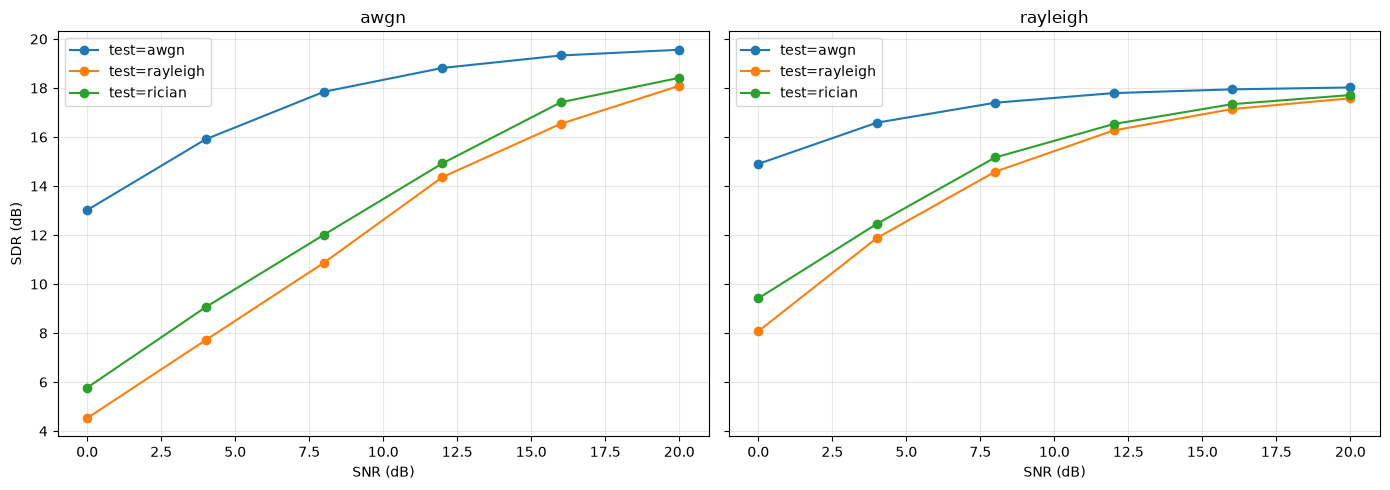

In [9]:
def eval_sdr_vs_snr(model, channel_kind, snr_range, rician_k=1.0):
    model.eval()
    ch = ChannelLayer(channel_kind, snr_db=snr_range[0], rician_k=rician_k)
    out = []
    for snr in snr_range:
        ch.snr_db = snr
        with torch.no_grad():
            x_hat = model(x, channel=ch)
        clip_sdrs = [
            sdr(deframe(x[i, 0].cpu().numpy()), deframe(x_hat[i, 0].cpu().numpy()))
            for i in range(x.shape[0])
        ]
        out.append(np.mean(clip_sdrs))
    return out

snr_range = list(range(0, 21, 4))
test_channels = ["awgn", "rayleigh", "rician"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for ax, (train_name, m) in zip(axes, models.items()):
    for test_kind in test_channels:
        sdrs = eval_sdr_vs_snr(m, test_kind, snr_range)
        ax.plot(snr_range, sdrs, marker="o", label=f"test={test_kind}")
    ax.set_title(train_name)
    ax.set_xlabel("SNR (dB)")
    ax.legend()
    ax.grid(alpha=0.3)
axes[0].set_ylabel("SDR (dB)")
plt.tight_layout()
plt.show()

## Cross-channel robustness gap (success criterion #3)

Quantify how much SDR drops when a model is tested on a channel it never saw during training, at a mid-range SNR.

In [10]:
probe_snr = [10]
gap_report = {}
for train_name, m in models.items():
    for test_kind in test_channels:
        s = eval_sdr_vs_snr(m, test_kind, probe_snr)[0]
        gap_report[(train_name, test_kind)] = s
        print(f"{train_name:16s} -> test={test_kind:10s} SDR={s:6.2f} dB @ {probe_snr[0]} dB SNR")

for train_name in models:
    same = gap_report[(train_name, train_name)]
    others = [v for (t, k), v in gap_report.items() if t == train_name and k != train_name]
    print(f"train={train_name}: max cross-channel SDR gap = {same - min(others):.2f} dB")

awgn             -> test=awgn       SDR= 18.44 dB @ 10 dB SNR
awgn             -> test=rayleigh   SDR= 13.35 dB @ 10 dB SNR
awgn             -> test=rician     SDR= 13.80 dB @ 10 dB SNR
rayleigh         -> test=awgn       SDR= 17.66 dB @ 10 dB SNR
rayleigh         -> test=rayleigh   SDR= 15.34 dB @ 10 dB SNR
rayleigh         -> test=rician     SDR= 15.77 dB @ 10 dB SNR
train=awgn: max cross-channel SDR gap = 5.09 dB
train=rayleigh: max cross-channel SDR gap = -0.43 dB


**Experiment — sweep Rician K high to low.** Watch the constellation (and SDR) morph from AWGN-like (K large) to Rayleigh-like (K=0).

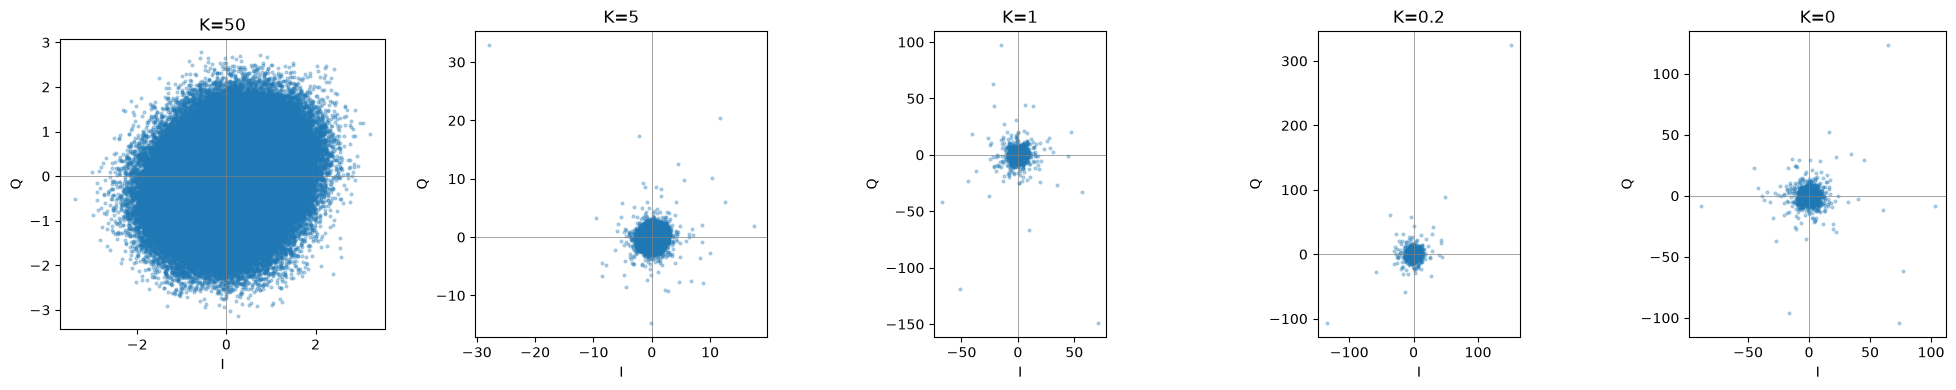

In [11]:
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for ax, k in zip(axes, [50, 5, 1, 0.2, 0]):
    ch = ChannelLayer("rician", snr_db=10.0, rician_k=max(k, 1e-6))
    with torch.no_grad():
        y = ch.impl.forward(x_iq, 10.0)
    plot_constellation(ax, y.cpu().numpy(), title=f"K={k}")
plt.tight_layout()
plt.show()

## Verify (success criterion #3)

In [12]:
max_gap = max(
    gap_report[(t, t)] - min(v for (tt, k), v in gap_report.items() if tt == t and k != t)
    for t in models
)
print(f"largest same-vs-cross-channel SDR gap: {max_gap:.2f} dB")
print("Stage 4 verified: one model handles multiple channels without retraining"
      " (gap is a robustness measure, not expected to be zero).")

largest same-vs-cross-channel SDR gap: 5.09 dB
Stage 4 verified: one model handles multiple channels without retraining (gap is a robustness measure, not expected to be zero).
